In [1]:
# train_pointcnn.py
import torch
import os
from glob import glob
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

from dataset.wireharness_dataset import WireHarenessDataset

# 訓練參數
data_dir = "D:/PartAnnotation/00000007/points"   # 資料集路徑
batch_size = 8
num_epochs = 200    # 訓練的最大epoch數量
num_classes = 2     # 模型分割的類別數

# 取得所有 .txt 檔案
all_files = sorted(glob(os.path.join(data_dir, "*.txt")))

# 資料集分割
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)   # 80% 訓練 / 20% 驗證

# 建立資料集
train_set = WireHarenessDataset(train_files)
val_set = WireHarenessDataset(val_files)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=4)  # 載入訓練集
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=4)     # 載入驗證集

Loading and sampling point cloud files...


Loading: 100%|██████████| 1511/1511 [1:29:22<00:00,  3.55s/file]


Loading and sampling point cloud files...


Loading: 100%|██████████| 378/378 [22:02<00:00,  3.50s/file]


In [5]:
# 檢查 train_loader 裡的點雲樣本點數
print("Train dataset point count per sample:")
for batch in train_loader:
    pcs = batch["pcd"]  # shape: [B, N, 3]
    print(f"Point cloud shape: {pcs.shape}")  # 印出整個 batch 的形狀
    for i in range(pcs.shape[0]):
        print(f" Sample {i}: {pcs[i].shape[0]} points")  # 印出每一個樣本的點數
    break  # 只印第一個 batch 就好

Train dataset point count per sample:
Point cloud shape: torch.Size([8, 1024, 3])
 Sample 0: 1024 points
 Sample 1: 1024 points
 Sample 2: 1024 points
 Sample 3: 1024 points
 Sample 4: 1024 points
 Sample 5: 1024 points
 Sample 6: 1024 points
 Sample 7: 1024 points


In [9]:
import importlib
# import pointcnn_seg

# importlib.reload(pointcnn_seg)  # 重新加載整個 module

# from pointcnn_seg import PointCNNSeg  # 再次導入類別

import pointcnn_seg_1024
importlib.reload(pointcnn_seg_1024)  # 重新加載整個 module
from pointcnn_seg_1024 import PointCNNSeg  # 再次導入類別

learning_rate = 1e-4  # 設定學習率   

# 模型
model = PointCNNSeg(num_classes=num_classes)

# 儲存驗證準確率最佳的模型權重（根據 val_acc_epoch）
checkpoint_callback = ModelCheckpoint(
    dirpath="C:/Users/mmdl/Desktop/Jiayuan/",    # 儲存模型權重的資料夾路徑
    filename="pointcnn-best_8_1024",             # 儲存模型權重的檔案名稱
    save_top_k=1,
    monitor="val_acc_epoch",
    mode="max"
)

# 早停： 一定數量的 epoch 內準確率沒提升就停止訓練
early_stop_callback = EarlyStopping(
    monitor="val_acc_epoch",         # 早停的評估依據: 驗證準確度
    patience=10,                     # 早停的評估標準1: 若 10 個 epoch 內準確率沒有增加就早停
    min_delta=0.0005,                # 早停的評估標準2: 準確率增加超過 0.0005 才算是準確率增加
    mode="max",
    verbose=True
)

# 訓練器
trainer = Trainer(
    max_epochs=num_epochs,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    callbacks=[checkpoint_callback, early_stop_callback],
    log_every_n_steps=10
)

# 開始訓練
trainer.fit(model, train_loader, val_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

   | Name           | Type               | Params
-------------------------------------------------------
0  | conv1          | XConv              | 9.2 K 
1  | conv2          | XConv              | 42.7 K
2  | conv3          | XConv              | 148 K 
3  | conv4          | XConv              | 512 K 
4  | conv_up4       | XConv              | 648 K 
5  | conv_up3       | XConv              | 253 K 
6  | conv_up2       | XConv              | 69.8 K
7  | conv_up1       | XConv              | 21.9 K
8  | mlp_out4       | Conv1d             | 262 K 
9  | mlp_out3       | Conv1d             | 65.8 K
10 | mlp_out2       | Conv1d             | 16.5 K
11 | mlp_out1       | Conv1d             | 4.2 K 
12 | fc_layer1      | Conv1d             | 8.2 K 
13 | Relu           | ReLU               | 0     
14 | DROP           | Dropout            | 0  

Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

C:\Users\mmdl\.conda\envs\pointcnn\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: The ``compute`` method of metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)  # noqa: B028
Metric val_acc_epoch improved. New best score: 0.857


...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Monitored metric val_acc_epoch did not improve in the last 10 records. Best score: 0.987. Signaling Trainer to stop.


In [10]:
print("Final train accuracy:", trainer.callback_metrics.get("train_acc_epoch"))
print("Final val accuracy:", trainer.callback_metrics.get("val_acc_epoch"))

Final train accuracy: tensor(0.)
Final val accuracy: tensor(0.9872)


In [11]:
ckpt_path = "C:/Users/mmdl/Desktop/Jiayuan/pointcnn-best_8_1024.ckpt"

model = PointCNNSeg.load_from_checkpoint(
    ckpt_path,
    num_classes=2,              # 模型分割的類別數
    weight_balance=None       
)

model.eval()
model.to("cuda" if torch.cuda.is_available() else "cpu")

correct = 0
total = 0

with torch.no_grad():
    for batch in train_loader:
        x, y = batch['pcd'], batch['label']
        x, y = x.to(model.device), y.to(model.device)

        y_hat = model(x)  # (B, C, N)
        y_hat = y_hat.permute(0, 2, 1)  # (B, N, C)
        pred = torch.argmax(y_hat, dim=-1)  # (B, N)

        correct += (pred.view(-1) == y.view(-1)).sum().item()
        total += y.numel()

train_acc = correct / total
print(f"Train Accuracy (post-hoc): {train_acc:.4f}")

C:\Users\mmdl\.conda\envs\pointcnn\lib\site-packages\pytorch_lightning\utilities\cloud_io.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_locat

Train Accuracy (post-hoc): 0.9894


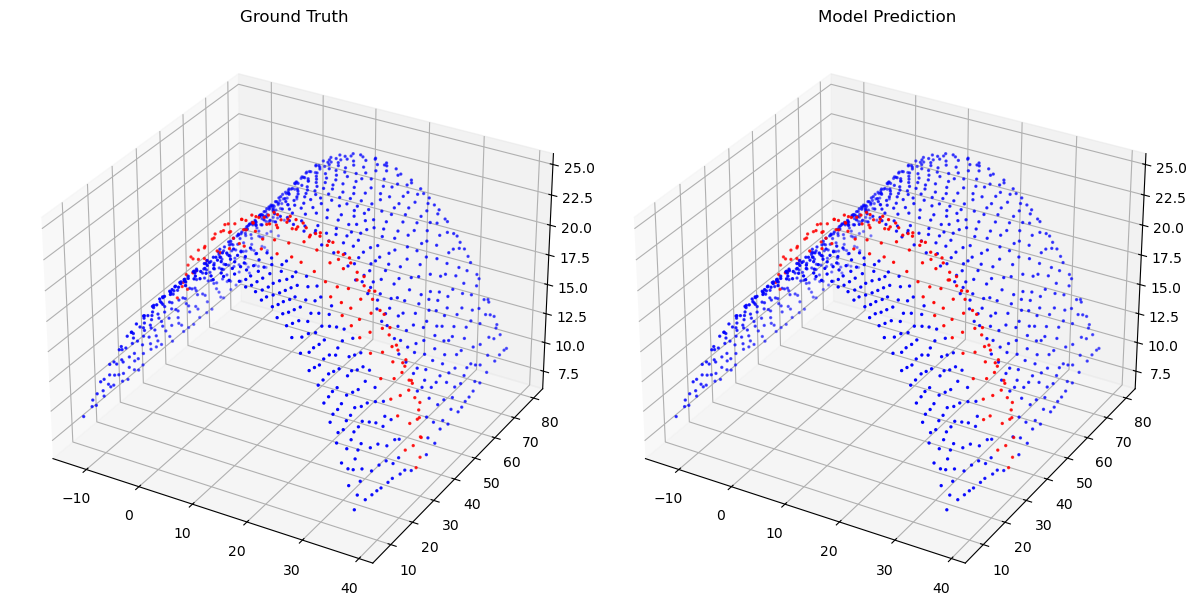

In [12]:
import random
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 隨機選一筆驗證資料
sample = random.choice(val_set)
pcd = sample['pcd'].unsqueeze(0).to(model.device)  # 加上 batch 維度
gt_label = sample['label'].numpy()

# 模型預測
model.eval()
with torch.no_grad():
    pred_logits = model(pcd)
    pred_classes = torch.argmax(pred_logits.squeeze(0).permute(1, 0), dim=1).cpu().numpy()

# 原始點雲座標
coords = pcd.squeeze(0).cpu().numpy()

# 畫圖
fig = plt.figure(figsize=(12, 6))

# Ground Truth
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.set_title("Ground Truth")
colors_gt = ['blue' if l == 0 else 'red' for l in gt_label]
ax1.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=colors_gt, s=2)

# Prediction
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.set_title("Model Prediction")
colors_pred = ['blue' if l == 0 else 'red' for l in pred_classes]
ax2.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=colors_pred, s=2)

plt.tight_layout()
plt.show()